In [1]:
import base64
from io import BytesIO




from IPython.display import HTML, display
from PIL import Image
from langchain_core.messages import HumanMessage

In [2]:
def convert_to_base64(pil_image):
    """
    PIL 이미지를 Base64로 인코딩된 문자열로 변환합니다.




    :param pil_image: PIL 이미지
    :return: 크기 조정된 Base64 문자열
    """




    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")  # 필요한 경우 형식을 변경할 수 있습니다.
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str


In [8]:
def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 문자열을 이미지로 표시합니다.




    :param img_base64:  Base64 문자열
    """
    # Base64 문자열을 소스로 사용하여 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))


In [3]:
def prompt_func(data):  # 프롬프트 함수를 정의합니다.
    text = data["text"]  # 데이터에서 텍스트를 가져옵니다.
    image = data["image"]  # 데이터에서 이미지를 가져옵니다.




    image_part = {  # 이미지 부분을 정의합니다.
        "type": "image_url",  # 이미지 URL 타입을 지정합니다.
        "image_url": f"data:image/jpeg;base64,{image}",  # 이미지 URL을 생성합니다.
    }




    content_parts = []  # 콘텐츠 부분을 저장할 리스트를 초기화합니다.




    text_part = {"type": "text", "text": text}  # 텍스트 부분을 정의합니다.




    content_parts.append(image_part)  # 이미지 부분을 콘텐츠 부분에 추가합니다.
    content_parts.append(text_part)  # 텍스트 부분을 콘텐츠 부분에 추가합니다.




    return [HumanMessage(content=content_parts)]  # HumanMessage 객체를 반환합니다.


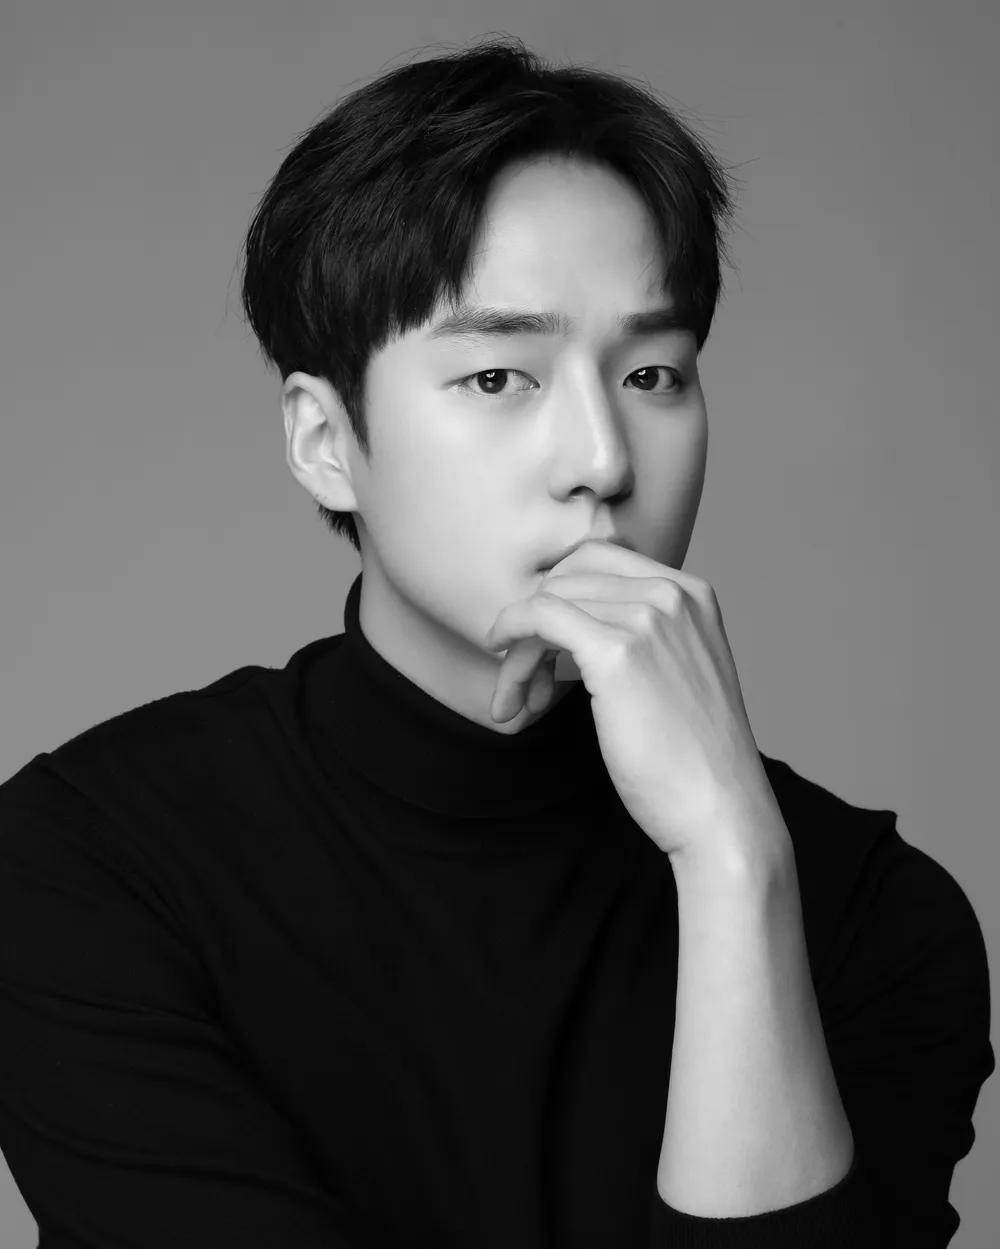

In [9]:
file_path =  "./images.webp"
pil_image = Image.open(file_path)




image_b64 = convert_to_base64(pil_image)




plt_img_base64(image_b64)


In [10]:


from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage




# ChatOllama 멀티모달 언어 모델을 불러옵니다.
llm = ChatOllama(model="llava:7b", temperature=0)




# 프롬프트 함수, 언어 모델, 출력 파서를 연결하여 체인을 생성합니다.
chain = prompt_func | llm | StrOutputParser()




query_chain = chain.invoke(  # 체인을 호출하여 쿼리를 실행합니다.
    # 텍스트와 이미지를 전달합니다.
    {"text": "Describe a picture in bullet points", "image": image_b64}
)




print(query_chain)  # 쿼리 결과를 출력합니다.


/home/oracle/miniconda3/envs/torch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 - The image is a portrait of a person.
- The individual appears to be a young adult male with short hair and a contemplative expression.
- He has a light skin tone and is wearing a black turtleneck sweater.
- His hands are clasped together in front of him, suggesting a thoughtful or introspective pose.
- The background is neutral and does not distract from the subject.
- There is no visible text on the image.
- The style of the photograph is realistic with a focus on capturing the person's expression and attire. 


In [12]:
import base64
from io import BytesIO




from IPython.display import HTML, display
from PIL import Image
from langchain_core.messages import HumanMessage




In [13]:
def convert_to_base64(pil_image):
    """
    PIL 이미지를 Base64로 인코딩된 문자열로 변환합니다.




    :param pil_image: PIL 이미지
    :return: 크기 조정된 Base64 문자열
    """




    buffered = BytesIO()
    pil_image.save(buffered, format="JPEG")  # 필요한 경우 형식을 변경할 수 있습니다.
    img_str = base64.b64encode(buffered.getvalue()).decode("utf-8")
    return img_str




In [14]:
def plt_img_base64(img_base64):
    """
    Base64로 인코딩된 문자열을 이미지로 표시합니다.




    :param img_base64:  Base64 문자열
    """
    # Base64 문자열을 소스로 사용하여 HTML img 태그 생성
    image_html = f'<img src="data:image/jpeg;base64,{img_base64}" />'
    # HTML을 렌더링하여 이미지 표시
    display(HTML(image_html))


In [15]:
def prompt_func(data):  # 프롬프트 함수를 정의합니다.
    text = data["text"]  # 데이터에서 텍스트를 가져옵니다.
    image = data["image"]  # 데이터에서 이미지를 가져옵니다.




    image_part = {  # 이미지 부분을 정의합니다.
        "type": "image_url",  # 이미지 URL 타입을 지정합니다.
        "image_url": f"data:image/jpeg;base64,{image}",  # 이미지 URL을 생성합니다.
    }




    content_parts = []  # 콘텐츠 부분을 저장할 리스트를 초기화합니다.




    text_part = {"type": "text", "text": text}  # 텍스트 부분을 정의합니다.




    content_parts.append(image_part)  # 이미지 부분을 콘텐츠 부분에 추가합니다.
    content_parts.append(text_part)  # 텍스트 부분을 콘텐츠 부분에 추가합니다.




    return [HumanMessage(content=content_parts)]  # HumanMessage 객체를 반환합니다.



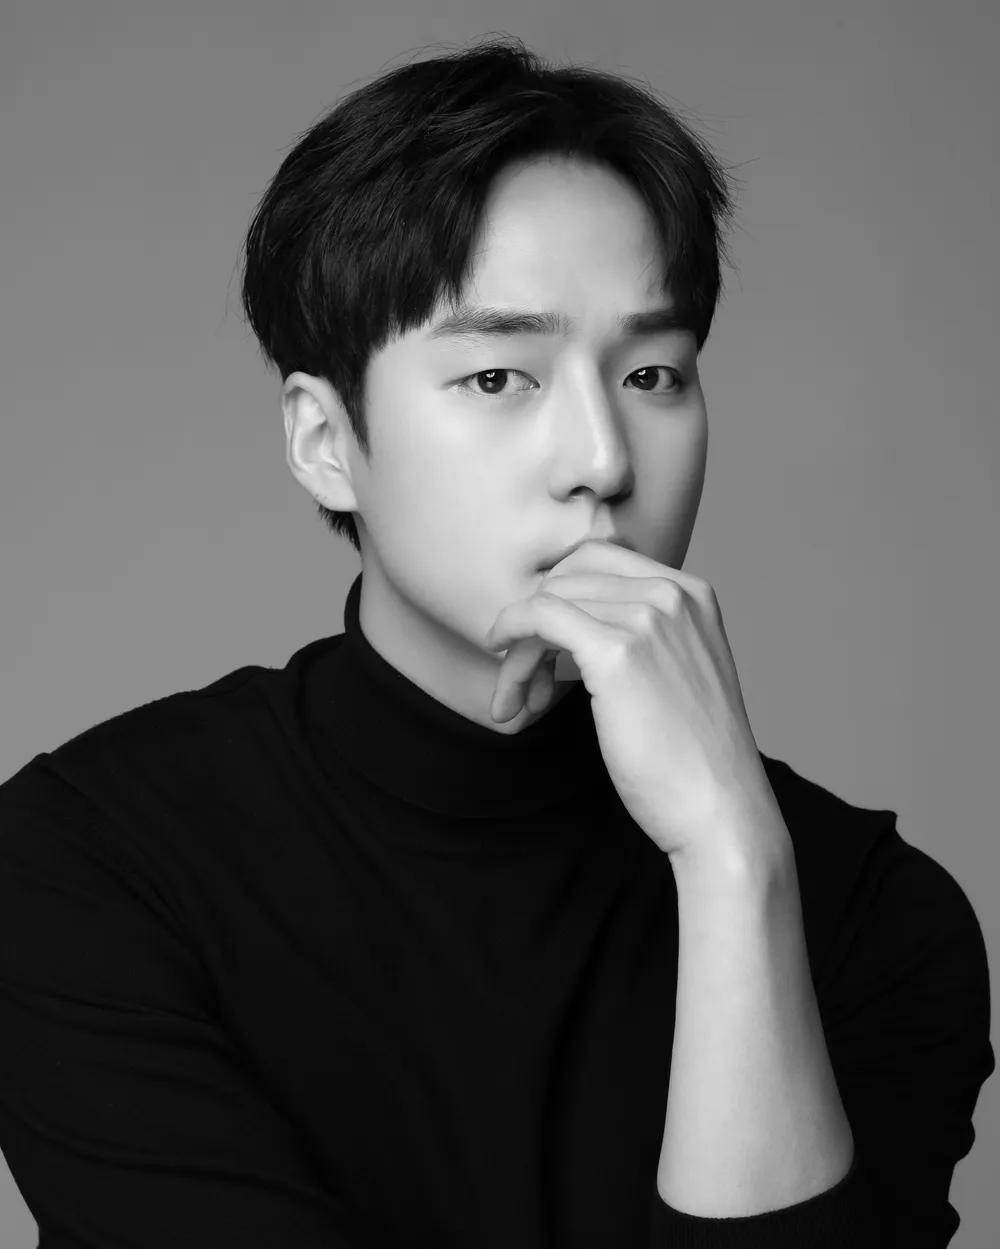

In [16]:
file_path =  "./images.webp"
pil_image = Image.open(file_path)




image_b64 = convert_to_base64(pil_image)




plt_img_base64(image_b64)


In [17]:
from langchain_core.output_parsers import StrOutputParser
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage




# ChatOllama 멀티모달 언어 모델을 불러옵니다.
llm = ChatOllama(model="llava:7b", temperature=0)




# 프롬프트 함수, 언어 모델, 출력 파서를 연결하여 체인을 생성합니다.
chain = prompt_func | llm | StrOutputParser()




query_chain = chain.invoke(  # 체인을 호출하여 쿼리를 실행합니다.
    # 텍스트와 이미지를 전달합니다.
    {"text": "Describe a picture in bullet points", "image": image_b64}
)




print(query_chain)  # 쿼리 결과를 출력합니다.




 - The image is a portrait of a person.
- The individual appears to be a young adult male with short hair and a contemplative expression.
- He has a light skin tone and is wearing a black turtleneck sweater.
- His hands are clasped together in front of him, suggesting a thoughtful or introspective pose.
- The background is neutral and does not distract from the subject.
- There is no visible text on the image.
- The style of the photograph is realistic with a focus on capturing the person's expression and attire. 


In [18]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification


from transformers import pipeline
tokenizer2 = AutoTokenizer.from_pretrained("nlp04/korean_sentiment_analysis_kcelectra")
model2 = AutoModelForSequenceClassification.from_pretrained("nlp04/korean_sentiment_analysis_kcelectra")
# Use a pipeline as a high-level helper




pipe2 = pipeline("text-classification", model="nlp04/korean_sentiment_analysis_kcelectra")


pipe2("야근합니다.")


2025-11-28 16:59:44.768487: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-28 16:59:45.388723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-28 16:59:47.773645: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


ValueError: Due to a serious vulnerability issue in `torch.load`, even with `weights_only=True`, we now require users to upgrade torch to at least v2.6 in order to use the function. This version restriction does not apply when loading files with safetensors.
See the vulnerability report here https://nvd.nist.gov/vuln/detail/CVE-2025-32434